In [1]:
from fastai.vision.all import *
import torch.nn.utils.prune as prune
import torch.nn as nn

In [2]:
model_path = 'fine_tuned_plant_classifier_model_v1_base.pkl'
learn = load_learner(model_path)
# Load the DataLoaders
with open('v1_dls.pkl', 'rb') as f:
    learn.dls = pickle.load(f)
print(len(learn.dls.valid_ds))

2297


In [3]:
print(learn.model)

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [4]:
learn.summary()

Sequential (Input shape: 25 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     25 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     25 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

In [5]:
for name, module in learn.model.named_modules():
    if isinstance(module, nn.Conv2d):
        if name.startswith("0.4"):  # layer1
            amount = 0.3
        elif name.startswith("0.5"):  # layer2
            amount = 0.6
        elif name.startswith("0.6"):  # layer3
            amount = 0.6
        elif name.startswith("0.7"):  # layer4
            amount = 0.7
        else:
            continue  # skip conv1 or head

        print(f"Pruning {name} with amount {amount}")
        prune.ln_structured(module, name="weight", amount=amount, n=2, dim=0)
        prune.remove(module, 'weight')

Pruning 0.4.0.conv1 with amount 0.3
Pruning 0.4.0.conv2 with amount 0.3
Pruning 0.4.1.conv1 with amount 0.3
Pruning 0.4.1.conv2 with amount 0.3
Pruning 0.5.0.conv1 with amount 0.6
Pruning 0.5.0.conv2 with amount 0.6
Pruning 0.5.0.downsample.0 with amount 0.6
Pruning 0.5.1.conv1 with amount 0.6
Pruning 0.5.1.conv2 with amount 0.6
Pruning 0.6.0.conv1 with amount 0.6
Pruning 0.6.0.conv2 with amount 0.6
Pruning 0.6.0.downsample.0 with amount 0.6
Pruning 0.6.1.conv1 with amount 0.6
Pruning 0.6.1.conv2 with amount 0.6
Pruning 0.7.0.conv1 with amount 0.7
Pruning 0.7.0.conv2 with amount 0.7
Pruning 0.7.0.downsample.0 with amount 0.7
Pruning 0.7.1.conv1 with amount 0.7
Pruning 0.7.1.conv2 with amount 0.7


In [6]:
torch.save(learn.model.state_dict(), "pruned7_plant_classifier.pth")
#learn.model.load_state_dict(torch.load("pruned7_plant_classifier.pth"))

In [7]:
learn.export('pruned7_plant_classifier.pkl')
# Save the DataLoaders separately (you can pickle them or use a different approach)
import pickle
with open('pruned7_dls.pkl', 'wb') as f:
    pickle.dump(learn.dls, f)

In [12]:
import time

# Load the original model (assuming you loaded it as a FastAI learner)
learn = load_learner('fine_tuned_plant_classifier_model_v1_base.pkl')
# Load the DataLoaders
with open('v1_dls.pkl', 'rb') as f:
    learn.dls = pickle.load(f)
    
# Get a sample image from the DataLoader
sample_image, _ = learn.dls.one_batch()
sample_image = sample_image[0].unsqueeze(0)  # Add batch dimension

# Measure inference time
start_time = time.time()
_ = learn.model(sample_image)
end_time = time.time()

inference_time_before = end_time - start_time
print(f"Inference time (before pruning): {inference_time_before:.6f} seconds")

Inference time (before pruning): 0.051398 seconds


In [13]:
# Assuming you've pruned and reloaded the model
learn = load_learner('pruned7_plant_classifier.pkl')
# Load the DataLoaders
with open('pruned7_dls.pkl', 'rb') as f:
    learn.dls = pickle.load(f)
# Measure inference time after pruning
start_time = time.time()
_ = learn.model(sample_image)
end_time = time.time()

inference_time_after = end_time - start_time
print(f"Inference time (after pruning): {inference_time_after:.6f} seconds")

Inference time (after pruning): 0.054975 seconds


In [14]:
# Freeze all layers except the last one (for faster fine-tuning)
learn.freeze_to(-2)

# Fine-tune the model
learn.fit_one_cycle(2, lr_max=1e-4)


epoch,train_loss,valid_loss,accuracy,time
0,1.206966,1.617724,0.645189,19:25
1,0.756359,1.309657,0.692643,18:35


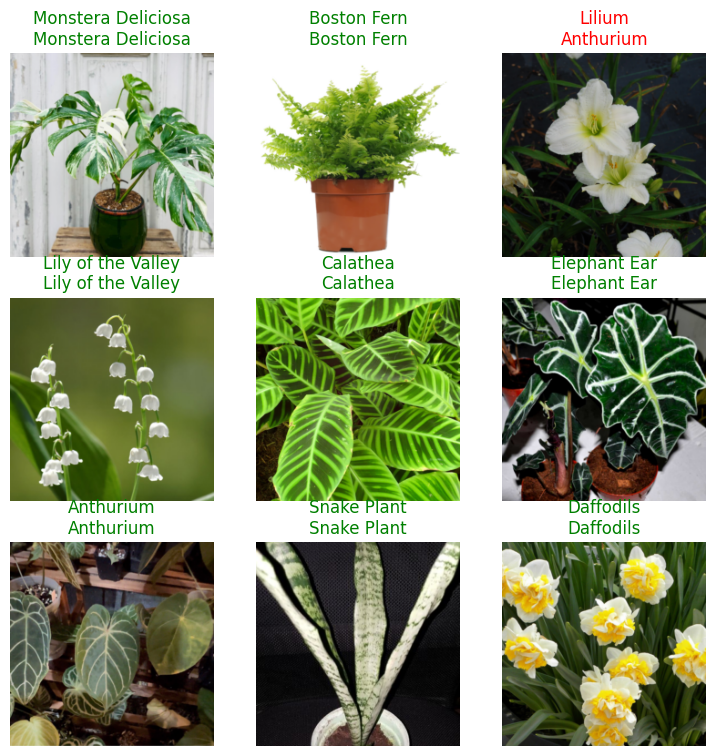

In [15]:
learn.show_results()

In [16]:
learn.export('frozenfine7_plant_classifier.pkl')
# Save the DataLoaders separately (you can pickle them or use a different approach)
import pickle
with open('frozenfine7_dls.pkl', 'wb') as f:
    pickle.dump(learn.dls, f)

In [17]:
from torchvision.models import resnet18

# Define a new ResNet18 model with fewer channels (manual adjustment needed)
smaller_model = resnet18(pretrained=False)

# Load pruned weights (strict=False ignores missing weights)
smaller_model.load_state_dict(torch.load("pruned7_plant_classifier.pth"), strict=False)

# Save the optimized model
torch.save(smaller_model.state_dict(), "pruned7_compact_model.pth")

c:\Users\rkurr\anaconda3\envs\endg411\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rkurr\anaconda3\envs\endg411\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [18]:
import os

# Compare file sizes
orig_size = os.path.getsize("base_model.pth") / 1e6  # Convert to MB
pruned_size = os.path.getsize("pruned7_compact_model.pth") / 1e6  # Convert to MB

print(f"Original Model Size: {orig_size:.2f} MB")
print(f"Pruned Model Size: {pruned_size:.2f} MB")
print(f"Reduction: {100 * (orig_size - pruned_size) / orig_size:.2f}%")

Original Model Size: 46.98 MB
Pruned Model Size: 46.84 MB
Reduction: 0.30%


In [5]:
from fastai.vision.all import *
model_path = 'v2pruned_plant_classifier.pkl'
learn = load_learner(model_path)
# Load the DataLoaders
with open('v2pruned_dls.pkl', 'rb') as f:
    learn.dls = pickle.load(f)
print(len(learn.dls.valid_ds))
# Eval mode and input example
model = learn.model.eval()
# Before pruning
total_params_before = sum(p.numel() for p in model.parameters())
print(f"Total parameters before pruning: {total_params_before}")
learn.validate()

2297
Total parameters before pruning: 9857776


(#2) [0.4182215929031372,0.8785372376441956]